<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# Linear Regression

In [notebook 01](01_Introduction_To_Supervised_Learning.ipynb) we walked through the
four steps of a supervised model — split, fit, predict, score — on six artificial
rows where the answer was exact.

Now the same four steps on real data. The goal of this notebook is to predict **how
much tip a taxi ride will receive**, from the distance travelled, the hour of the
day and how long the ride took. Since a tip is a continuous amount of money rather
than a category, this is a **regression** problem.

The result is not going to be good, and that is the interesting part: most of this
notebook is about how you *find out* that a model is not good.

---

## Contents

1. [What linear regression does](#idea)
2. [The data](#data)
3. [Choosing the features](#features)
4. [Training the model](#train)
5. [Measuring the error](#evaluation)
6. [The verdict](#verdict)

<a id="idea"></a>
## 1. What linear regression does

Linear regression draws **one straight line** through the data, positioned so that
it passes as close as possible to all the points at once.

![Linear regression](../../images/ml_linear_regression.svg)

With several features it is no longer a line on paper, but the formula is the same
shape — every feature is multiplied by its own parameter, and the products are added
up:

$$\hat y = b_{0}x_{0} + b_{1}x_{1} + \dots + b_{n}x_{n}$$

| Symbol | Meaning |
|---|---|
| $\hat y$ | the predicted output |
| $x_{i}$ | one feature |
| $b_{i}$ | one parameter of the model |

Training means finding the $b_{i}$ that fit the data best. Those parameters are
everything the model knows — exactly like the weights and biases of a neural
network in the Deep Learning chapter.

"Best" has to mean something precise, and here it means **least squares**: the
parameters are chosen so that the sum of the squared distances between the line and
the actual points is as small as it can be.

$$\min_{\mathbf{b}} \; \sum_{i=1}^{n} \left( y_i - \hat y_i \right)^{2}$$

Linear regression is a fortunate case, because that minimum can be **written down
directly** rather than searched for. The solution is the *normal equation*:

$$\mathbf{b} = \left( \mathbf{X}^{\mathsf{T}} \mathbf{X} \right)^{-1} \mathbf{X}^{\mathsf{T}} \mathbf{y}$$

with $\mathbf{X}$ the whole table of features and $\mathbf{y}$ the column of labels.
The entire dataset goes in on the right, every parameter comes out on the left, in
one calculation — which is why `fit()` returns instantly here.

Most models have no such formula and must walk towards their parameters step by step
instead. That is what the Deep Learning chapter shows.

<a id="data"></a>
## 2. The data

We use the New York City green taxi trips — one row per ride, with pickup and
dropoff times, distance, fare, tip and more.

*Data source: [https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)*

The full file holds 68,211 rides. We take a random sample of 1000, which is plenty
for this example and keeps everything fast. `random_state=42` fixes which 1000, so
that every number in this notebook stays the same when you re-run it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('../../files/green_tripdata_2023-01.parquet', engine='pyarrow')
df = df.sample(1000, random_state=42)

df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
13670,2,2023-01-08 00:02:11,2023-01-08 00:08:41,N,1.0,7,129,1.0,2.01,11.4,1.0,0.5,0.00,0.0,None,1.0,13.90,1.0,1.0,0.0
22876,2,2023-01-12 14:16:43,2023-01-12 14:27:51,N,1.0,74,75,1.0,1.70,12.1,0.0,0.5,0.00,0.0,None,1.0,13.60,2.0,1.0,0.0
54793,2,2023-01-27 14:12:32,2023-01-27 14:22:47,N,1.0,43,74,1.0,1.65,11.4,0.0,0.5,2.58,0.0,None,1.0,15.48,1.0,1.0,0.0
25750,2,2023-01-13 17:49:21,2023-01-13 17:53:08,N,1.0,43,151,1.0,0.78,6.5,2.5,0.5,2.10,0.0,None,1.0,12.60,1.0,1.0,0.0
48410,2,2023-01-24 18:20:00,2023-01-24 18:25:48,N,1.0,166,41,2.0,0.90,5.5,1.0,0.5,1.46,0.0,None,0.3,8.76,1.0,1.0,0.0


Two of the three features we want do not exist in the file yet, and have to be
derived from the two timestamp columns.

The **hour of the pickup** is one number out of the timestamp.

In [2]:
df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour

df['pickup_hour'].head()

13670     0
22876    14
54793    14
25750    17
48410    18
Name: pickup_hour, dtype: int32

The **duration of the ride** is the difference between the two timestamps.
Subtracting them gives a time span, which is then converted to whole minutes.

In [3]:
df['ride_duration'] = df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']
df['ride_duration_minutes'] = df['ride_duration'].dt.total_seconds().div(60).astype(int)

df[['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'ride_duration',
    'ride_duration_minutes']].head()

,lpep_pickup_datetime,lpep_dropoff_datetime,ride_duration,ride_duration_minutes
13670,2023-01-08 00:02:11,2023-01-08 00:08:41,0 days 00:06:30,6
22876,2023-01-12 14:16:43,2023-01-12 14:27:51,0 days 00:11:08,11
54793,2023-01-27 14:12:32,2023-01-27 14:22:47,0 days 00:10:15,10
25750,2023-01-13 17:49:21,2023-01-13 17:53:08,0 days 00:03:47,3
48410,2023-01-24 18:20:00,2023-01-24 18:25:48,0 days 00:05:48,5


<a id="features"></a>
## 3. Choosing the features

Before training anything, it is worth looking at which columns actually move
together. We keep a handful of numeric columns and plot every one against every
other — a **pairplot**.

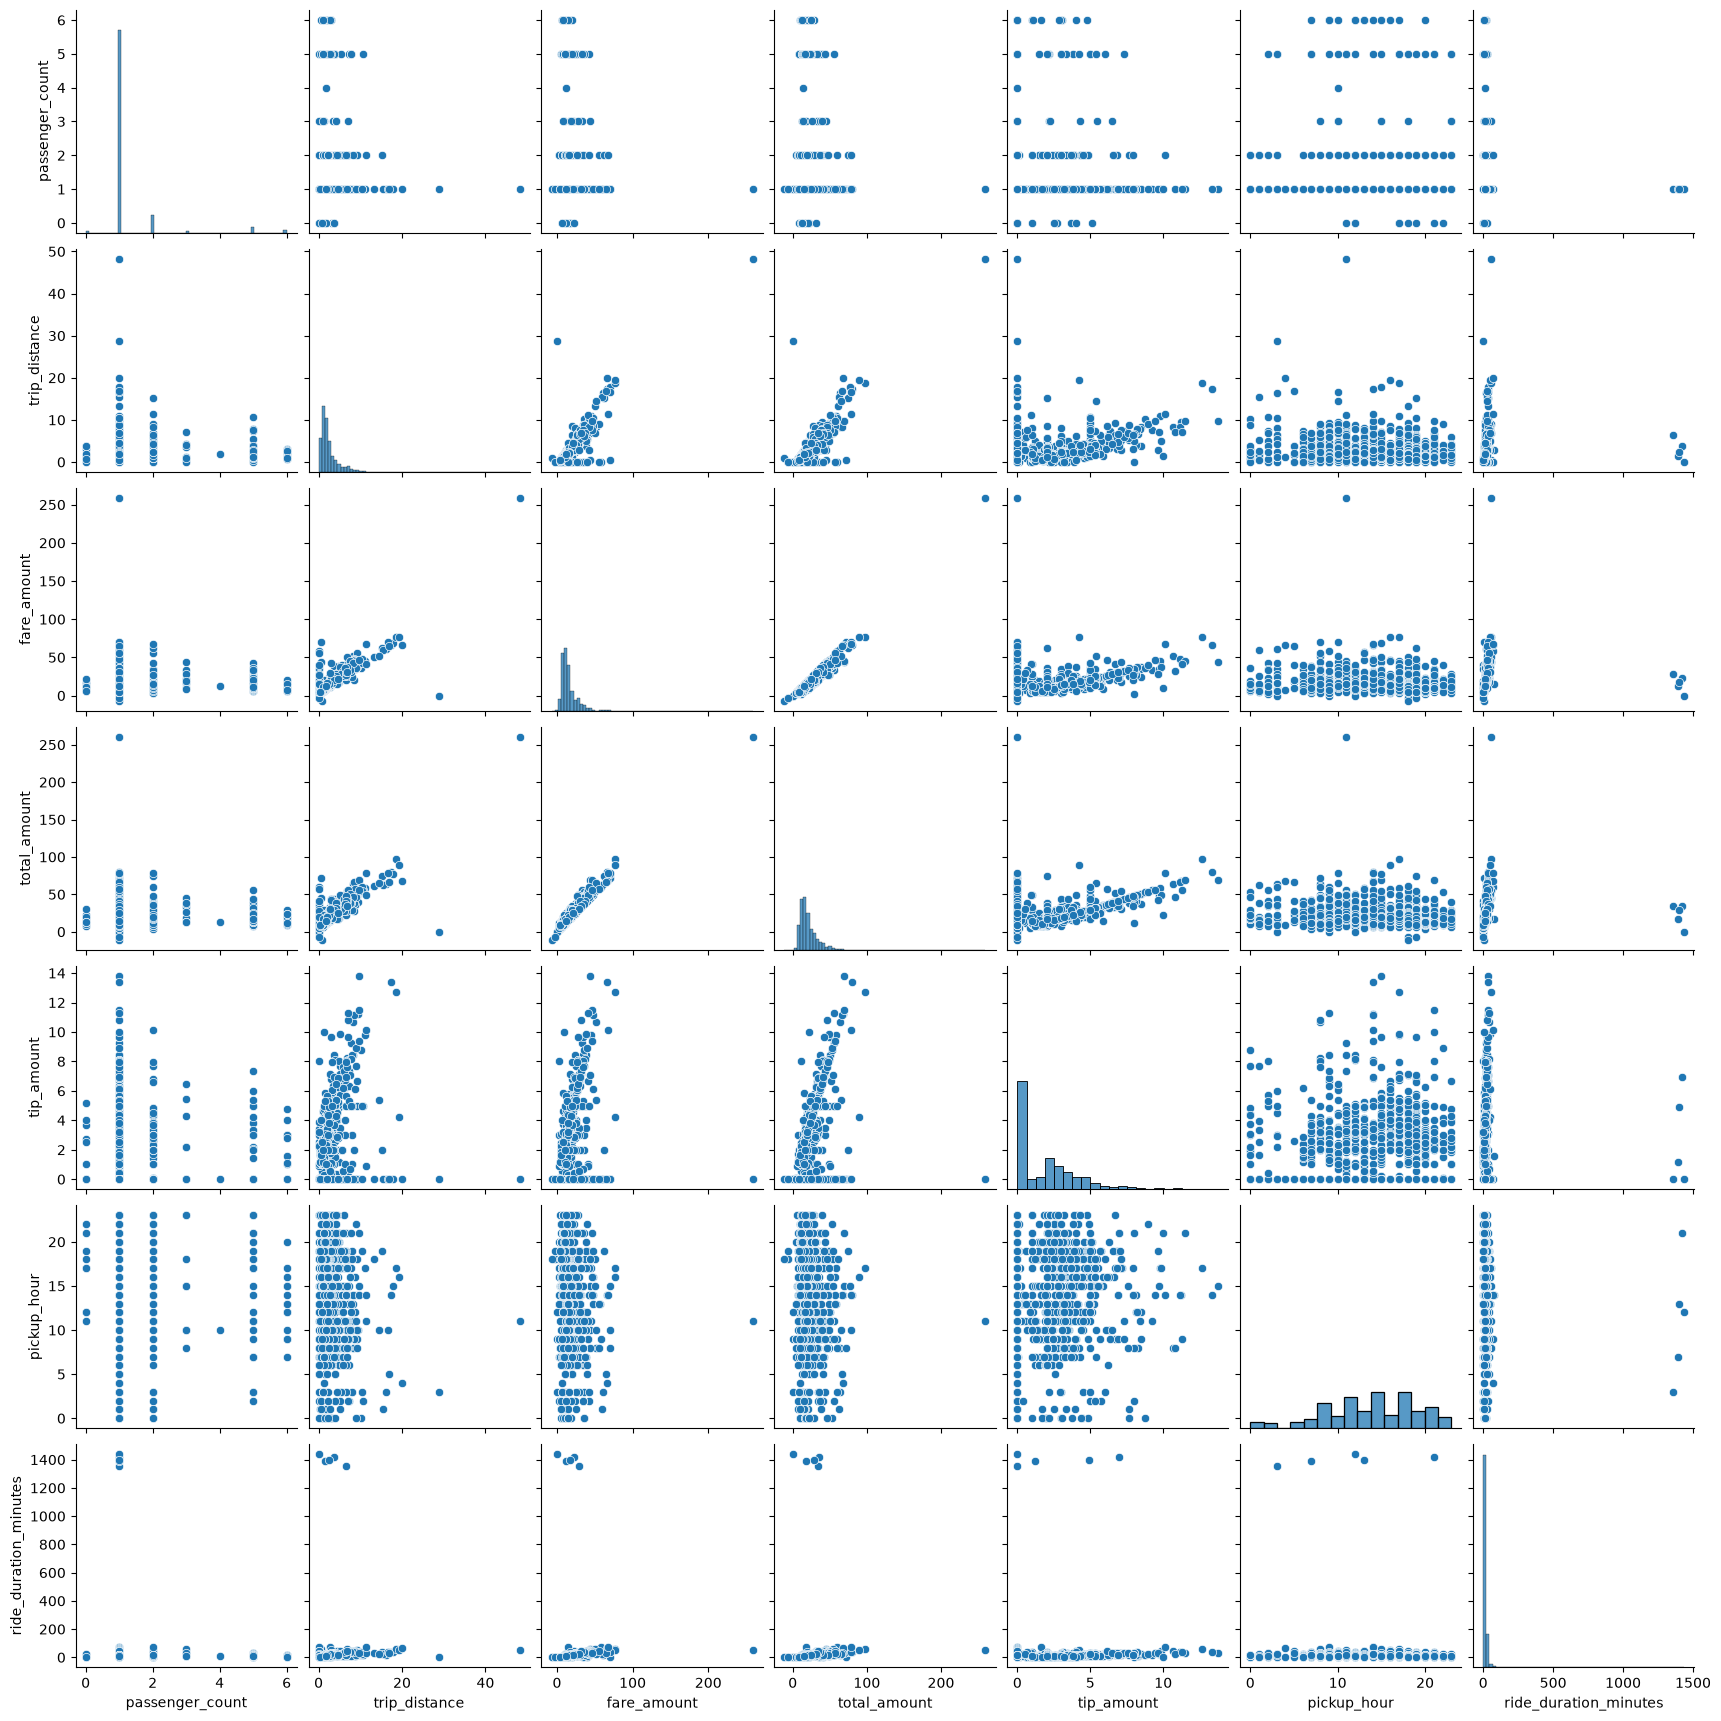

In [4]:
df = df[['passenger_count', 'trip_distance', 'fare_amount', 'total_amount',
         'tip_amount', 'pickup_hour', 'ride_duration_minutes']]

sns.pairplot(df)
plt.show()

The diagonal shows the distribution of each column on its own; every other panel is
one column plotted against another. What we are looking for is a panel where the
points form a line rather than a cloud — that would mean the two are related.

Three of them, plotted larger against the total amount.

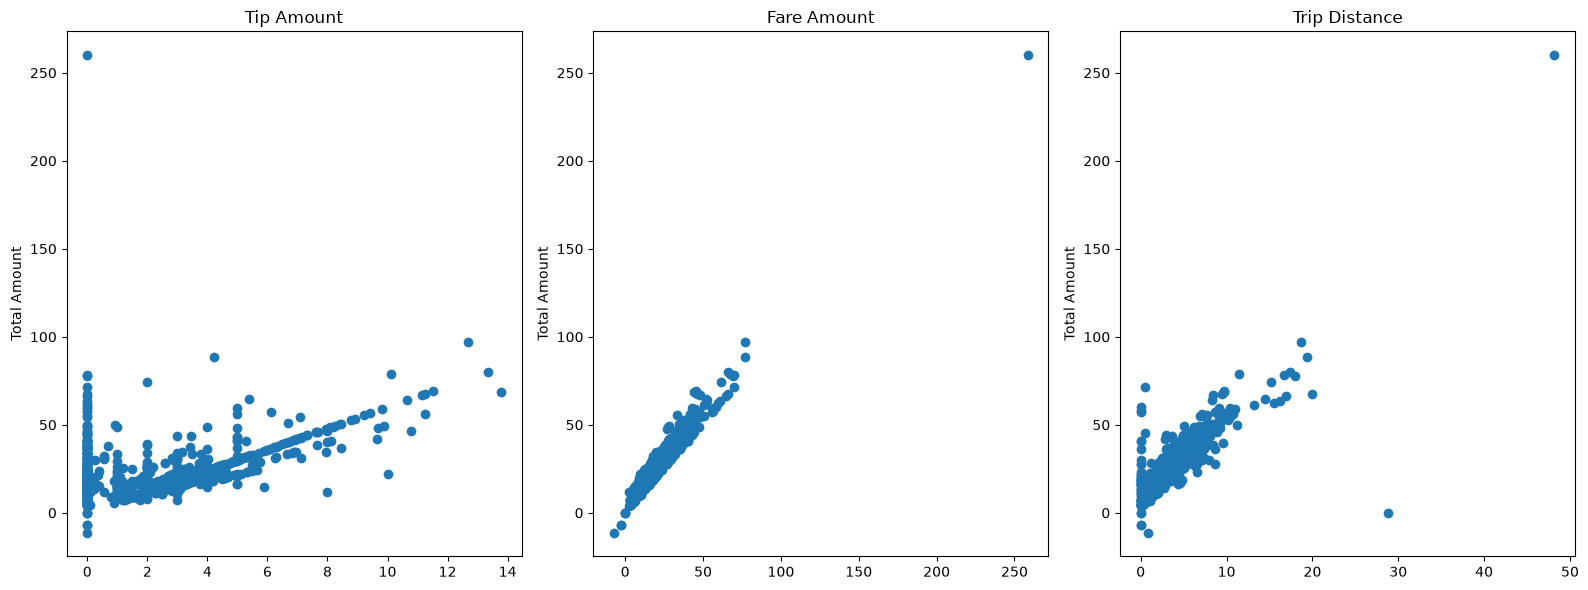

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))

axes[0].plot(df['tip_amount'], df['total_amount'], 'o')
axes[0].set_ylabel("Total Amount")
axes[0].set_title("Tip Amount")

axes[1].plot(df['fare_amount'], df['total_amount'], 'o')
axes[1].set_ylabel("Total Amount")
axes[1].set_title("Fare Amount")

axes[2].plot(df['trip_distance'], df['total_amount'], 'o')
axes[2].set_ylabel("Total Amount")
axes[2].set_title("Trip Distance")

plt.tight_layout()
plt.show()

`fare_amount` against `total_amount` is almost a perfect line — unsurprisingly,
since the total is largely made up of the fare. That makes it a useless feature for
our purpose: predicting the tip from the total would be predicting a number from
itself.

So we predict the **tip** from three things that are genuinely independent of it.

In [6]:
X = df[['trip_distance', 'pickup_hour', 'ride_duration_minutes']]   # features
y = df['tip_amount']                                                # label

X.head()

,trip_distance,pickup_hour,ride_duration_minutes
13670,2.01,0,6
22876,1.70,14,11
54793,1.65,14,10
25750,0.78,17,3
48410,0.90,18,5


<a id="train"></a>
## 4. Training the model

The same four steps as in notebook 01, now on 1000 rows. 20% is held back for
testing.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("training rows:", len(X_train))
print("test rows:    ", len(X_test))

training rows: 800
test rows:     200


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.21,0.03,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['trip_distance','pickup_hour','ride_duration_minutes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.157
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [9]:
prediction = model.predict(X_test)

prediction[:10].round(3)

array([2.219, 2.401, 1.802, 3.291, 2.973, 1.798, 1.666, 1.622, 1.858,
       2.902])

<a id="evaluation"></a>
## 5. Measuring the error

We have a trained model and a set of predictions. How good are they?

The obvious answer is to take the difference between each prediction and the true
value, and average it. Because a difference can be negative, the absolute value is
used — this is the **mean absolute error**:

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat y_i \right|$$

It has one weakness. A model that is slightly off on every ride and a model that is
correct on almost all of them but catastrophically wrong on a few can produce the
same MAE — the extreme mistakes get averaged away.

Squaring the difference instead of taking its absolute value fixes that, because a
large error squared becomes very large indeed. That is the **mean squared error**:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat y_i \right)^2$$

Now the units are wrong: squaring dollars gives dollars-squared, which means
nothing. Taking the square root at the end brings them back:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} \left( y_i - \hat y_i \right)^2}$$

**Root mean squared error** punishes large mistakes *and* is measured in the same
unit as the label, which makes it the usual choice.

### What counts as a good RMSE?

It depends entirely on what is being predicted. An RMSE of 50 € is excellent when
estimating the price of a house and absurd when estimating the cost of a taxi ride.

The number only means something next to the scale of the label itself.

In [10]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, prediction))

print(f"average tip: {y.mean():.3f}")
print(f"RMSE:        {rmse:.3f}")

average tip: 2.025
RMSE:        2.264


<a id="verdict"></a>
## 6. The verdict

**The typical error is larger than the typical tip.** A model whose average mistake
exceeds the value it is predicting has told us nothing — guessing the average tip
for every ride would do about as well.

That is a perfectly normal outcome, and worth sitting with. The features we chose
simply do not determine the tip: how far someone travelled and at what hour says
little about how generous they felt.

There is also something specific to this dataset. **41% of the sampled rides record
a tip of exactly zero** — and that is not because nobody tipped. Of the rides paid
in cash, *every single one* shows a tip of 0.00, because a cash tip never passes
through the meter. Almost a third of our training data therefore carries a label
that is simply wrong, and no model can be expected to predict it.

There are two honest ways forward — find better features, or try a model that can
represent something other than a straight line. [Notebook
03](03_Cross_Validation_And_Grid_Search.ipynb) is about how to compare such
alternatives without fooling yourself.